# PKCERT AI & Software Development Internship

## Task 07
Machine Learning Foundations: Train/Test Split, Linear Regression, Overfitting & Underfitting

Submitted By: Ayesha Bhatti


In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Dataset
from sklearn.datasets import fetch_california_housing

# Model selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve

# Linear Regression
from sklearn.linear_model import LinearRegression

# Evaluation Metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Polynomial Regression
from sklearn.preprocessing import PolynomialFeatures

# Part A – ML Theory: Train/Test Split

## 1. Why is a dataset split into training and testing sets?

Machine Learning models learn patterns from data. If the same data is used for both training and evaluation, the model may simply memorize the data instead of learning meaningful relationships.

To avoid this problem, the dataset is divided into two parts:

- **Training Set:** Used to train the model.
- **Testing Set:** Used to evaluate the model on unseen data.

This process helps measure how well the model generalizes to new data and reduces the risk of overestimating its performance.

## 2. Common Train/Test Split Ratios

Several train/test split ratios are commonly used in machine learning.

| Split Ratio | When to Use |
|-------------|-------------|
| 80/20 | Most commonly used; provides a good balance between training and testing data. |
| 70/30 | Useful for smaller datasets where more testing data is desired. |
| 90/10 | Suitable for very large datasets where the model still has plenty of training data. |
| 60/40 | Used when more evaluation data is needed. |

The choice of split ratio depends on the size of the dataset and the complexity of the machine learning problem.

In [2]:
# Load California Housing Dataset

housing = fetch_california_housing(as_frame=True)

# Convert to DataFrame
df = housing.frame

# Display first five rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
# Features
X = df.drop("MedHouseVal", axis=1)

# Target
y = df["MedHouseVal"]

# Split dataset

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (16512, 8)
Testing Features: (4128, 8)
Training Labels: (16512,)
Testing Labels: (4128,)


## 4. What is the role of `random_state`?

The `random_state` parameter controls how the dataset is randomly divided into training and testing sets.

Using the same value (for example, `random_state=42`) ensures that the data is split in the same way every time the code is executed. This makes the experiment reproducible, allowing others to obtain the same results and making it easier to compare different models.

## 5. What is a Validation Set?

A validation set is a portion of the dataset used during model development to tune hyperparameters and compare different models.

The three datasets have different purposes:

- **Training Set:** Used to train the model.
- **Validation Set:** Used to improve and tune the model.
- **Testing Set:** Used only once to evaluate the final model's performance on unseen data.

Unlike the validation set, the testing set should not be used during model training or model selection.

# Part B – ML Theory: Overfitting, Underfitting & Bias-Variance Tradeoff

## 1. What are Overfitting and Underfitting?

### Overfitting

Overfitting occurs when a machine learning model learns not only the underlying patterns in the training data but also the noise and random fluctuations. As a result, it performs very well on the training data but poorly on new, unseen data.

**Example:**
Suppose a model is trained to predict house prices. If it memorizes the exact prices of the training houses instead of learning the relationship between features (such as area and number of rooms), it may fail to predict prices accurately for new houses.

---

### Underfitting

Underfitting occurs when a model is too simple to capture the relationship between the input features and the target variable. It performs poorly on both the training data and the testing data.

**Example:**
If house prices depend on many factors but the model uses only one feature with a simple straight line, it may not fit the data well, resulting in poor predictions.

## 2. Explain the Bias-Variance Tradeoff

The bias-variance tradeoff is one of the most important concepts in machine learning.

- **Bias** is the error caused by overly simple assumptions in the learning algorithm. High bias can lead to underfitting because the model is too simple to learn the data properly.

- **Variance** is the error caused by the model being too sensitive to small changes in the training data. High variance can lead to overfitting because the model memorizes the training data instead of learning general patterns.

A good machine learning model balances bias and variance to achieve the best performance on unseen data.

## 3. Techniques to Reduce Overfitting

Some practical techniques to reduce overfitting include:

1. **Collect More Training Data**
   - More data helps the model learn general patterns instead of memorizing the training examples.

2. **Cross-Validation**
   - Cross-validation evaluates the model on different subsets of the data, providing a more reliable estimate of performance.

3. **Use Simpler Models**
   - Choosing a less complex model can reduce the chance of memorizing noise.

4. **Regularization**
   - Techniques such as Ridge and Lasso Regression add penalties to large coefficients, reducing model complexity.

5. **Early Stopping**
   - Training is stopped before the model begins to memorize the training data.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

degrees = [1, 2, 3, 4]

training_error = []
testing_error = []

for degree in degrees:

    poly = PolynomialFeatures(degree)

    X_poly = poly.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(X_poly,y,test_size=0.2,random_state=42)

    model = LinearRegression()

    model.fit(X_train, y_train)

    train_predictions = model.predict(X_train)

    test_predictions = model.predict(X_test)

    train_mse = mean_squared_error(y_train, train_predictions)

    test_mse = mean_squared_error(y_test, test_predictions)

    training_error.append(train_mse)

    testing_error.append(test_mse)

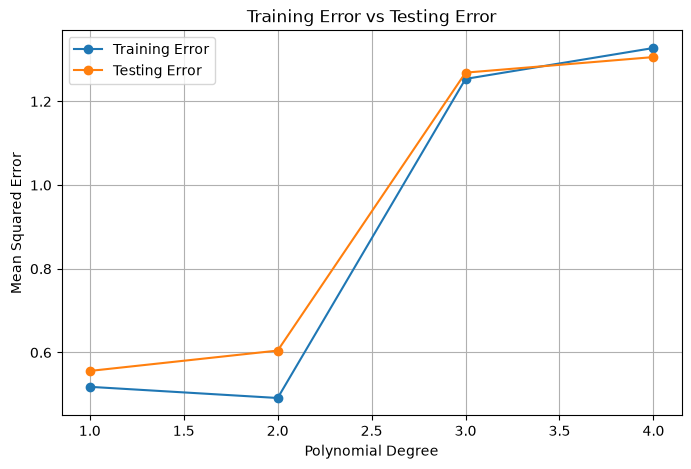

In [5]:
plt.figure(figsize=(8,5))

plt.plot(degrees, training_error, marker='o', label='Training Error')

plt.plot(degrees, testing_error, marker='o', label='Testing Error')

plt.xlabel("Polynomial Degree")

plt.ylabel("Mean Squared Error")

plt.title("Training Error vs Testing Error")

plt.legend()

plt.grid(True)

plt.show()

### Explanation of the Graph

The graph shows how the training error and testing error change as the model becomes more complex.

- At lower polynomial degrees, both training and testing errors are relatively high, indicating underfitting.
- As the degree increases, both errors decrease because the model learns more complex patterns.
- If the polynomial degree becomes too high, the training error continues to decrease while the testing error starts increasing. This indicates overfitting, where the model memorizes the training data instead of generalizing to unseen data.

The ideal model is the one where the testing error is the lowest and the gap between training and testing error is small.

## 5. How to Diagnose Overfitting or Underfitting?

A model's performance can be diagnosed by comparing its training and testing errors.

- If both training error and testing error are high, the model is **underfitting** because it cannot learn the data properly.

- If training error is very low but testing error is much higher, the model is **overfitting** because it has memorized the training data.

- If both training error and testing error are low and close to each other, the model is **well generalized** and is expected to perform well on unseen data.

# Part C – Linear Regression: Theory & Implementation

## 1. Explain Simple Linear Regression and Multiple Linear Regression

### Simple Linear Regression

Simple Linear Regression is a supervised machine learning algorithm used to predict a continuous value based on a single independent variable. It models the relationship between one input feature and one output variable using a straight line.

The mathematical equation is:

\[
y = mx + b
\]

Where:
- **y** = Predicted (dependent) variable
- **x** = Independent variable (feature)
- **m** = Slope of the line (coefficient)
- **b** = Intercept (constant)

The slope (**m**) shows how much the predicted value changes when the input feature increases by one unit.

---

### Multiple Linear Regression

Multiple Linear Regression is an extension of Simple Linear Regression that uses two or more independent variables to predict a continuous output.

The mathematical equation is:

\[
y = b₀ + b₁x₁ + b₂x₂ + ... + bₙxₙ
\]

Where:
- **y** = Predicted value
- **b₀** = Intercept
- **b₁, b₂, ..., bₙ** = Coefficients of the features
- **x₁, x₂, ..., xₙ** = Independent variables

Since the California Housing dataset contains multiple features, this project uses Multiple Linear Regression.

## 2. How Are the Model's Coefficients Learned?

A Linear Regression model learns the best coefficients by minimizing the prediction error.

The most common cost function is **Mean Squared Error (MSE)**, which calculates the average squared difference between the actual values and the predicted values.

The objective is to find the values of the coefficients that minimize this error.

Two common methods are used:

- **Gradient Descent:** Updates the coefficients iteratively until the error becomes as small as possible.
- **Normal Equation:** Computes the optimal coefficients directly using matrix operations.

Scikit-learn's `LinearRegression` automatically finds the optimal coefficients without requiring manual implementation.

In [6]:
# Features (Independent Variables)
X = df.drop("MedHouseVal", axis=1)

# Target (Dependent Variable)
y = df["MedHouseVal"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (20640, 8)
Target Shape: (20640,)


In [ ]:
# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Create the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [8]:
# Display model coefficients

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,MedInc,0.448675
1,HouseAge,0.009724
2,AveRooms,-0.123323
3,AveBedrms,0.783145
4,Population,-0.000002
5,AveOccup,-0.003526
6,Latitude,-0.419792
7,Longitude,-0.433708


In [9]:
print("Intercept:", model.intercept_)

Intercept: -37.02327770606416


In [10]:
# Make predictions
predictions = model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Mean Squared Error (MSE): 0.5558915986952442
R² Score: 0.575787706032451


### Interpretation of the Results

The Mean Squared Error (MSE) measures the average squared difference between the predicted values and the actual values. A lower MSE indicates better model performance.

The R² Score measures how well the independent variables explain the variation in the target variable.

- An R² score close to **1** indicates excellent predictive performance.
- An R² score close to **0** indicates poor predictive performance.

The obtained results suggest that the Linear Regression model is able to explain a significant portion of the variation in house prices.

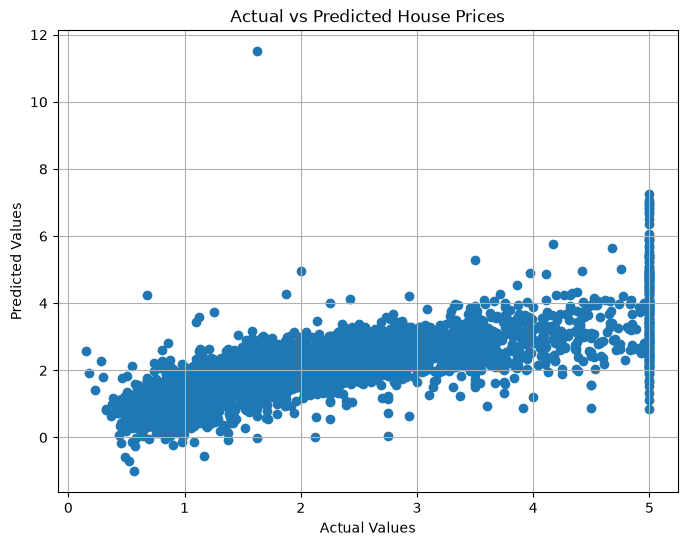

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted House Prices")

plt.grid(True)

plt.show()

### Explanation of the Plot

The scatter plot compares the actual house prices with the values predicted by the Linear Regression model.

If the predicted values are close to the actual values, the points will lie near an imaginary diagonal line. A tighter clustering of points indicates better prediction accuracy.

Any large deviations from this trend represent prediction errors made by the model.

In [12]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

comparison.head(10)

,Actual,Predicted
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


# Part D – Practical Coding Session

In [13]:
# Save dataset as CSV
df.to_csv("california_housing.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [14]:
# Load the raw CSV dataset
df = pd.read_csv("california_housing.csv")

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [15]:
# Check missing values
print(df.isnull().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


### Handling Missing Values

The California Housing dataset does not contain missing values. Therefore, no imputation was required. If missing values were present, they could be handled using techniques such as replacing them with the mean, median, or mode, depending on the data type.

In [16]:
# Create a sample categorical column
df["Region"] = "Urban"

# Display first five rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,Region
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,Urban
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,Urban
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,Urban
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,Urban
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,Urban


In [17]:
# Encode categorical data
df = pd.get_dummies(df, columns=["Region"], drop_first=True)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Encoding Categorical Data

The original California Housing dataset contains only numerical features. To demonstrate categorical encoding, a sample column named **Region** was created and encoded using one-hot encoding with `pd.get_dummies()`.

In [ ]:
def split_data(data, target_column, test_size):

    X = data.drop(target_column, axis=1)
    y = data[target_column]

    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=test_size,random_state=42)

    print("Training Features:", X_train.shape)
    print("Testing Features:", X_test.shape)
    print("Training Labels:", y_train.shape)
    print("Testing Labels:", y_test.shape)

    return X_train, X_test, y_train, y_test

In [19]:
X_train, X_test, y_train, y_test = split_data(df,"MedHouseVal",0.2)

Training Features: (16512, 8)
Testing Features: (4128, 8)
Training Labels: (16512,)
Testing Labels: (4128,)


In [20]:
ratios = [0.4, 0.2, 0.1]

results = []

for ratio in ratios:

    X_train, X_test, y_train, y_test = split_data(df,"MedHouseVal",ratio)

    model = LinearRegression()

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mse = mean_squared_error(y_test, predictions)

    r2 = r2_score(y_test, predictions)

    results.append([
        f"{int((1-ratio)*100)}/{int(ratio*100)}",
        mse,
        r2
    ])

comparison = pd.DataFrame(
    results,
    columns=[
        "Train/Test Split",
        "Mean Squared Error",
        "R² Score"
    ]
)

comparison

Training Features: (12384, 8)
Testing Features: (8256, 8)
Training Labels: (12384,)
Testing Labels: (8256,)
Training Features: (16512, 8)
Testing Features: (4128, 8)
Training Labels: (16512,)
Testing Labels: (4128,)
Training Features: (18576, 8)
Testing Features: (2064, 8)
Training Labels: (18576,)
Testing Labels: (2064,)


,Train/Test Split,Mean Squared Error,R² Score
0,60/40,0.543595,0.593940
1,80/20,0.555892,0.575788
2,90/10,0.559002,0.580835


### Comparison of Different Train/Test Splits

The model was trained using three different train/test split ratios.

Although the evaluation metrics varied slightly, all three ratios produced similar performance. The **80/20** split offered a good balance between training and testing data and is commonly used in machine learning applications.

In [ ]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

scores = cross_val_score(LinearRegression(),X,y,cv=5,scoring="r2")

print("Cross Validation Scores:")

print(scores)

print()

print("Average R² Score:")

print(scores.mean())

Cross Validation Scores:
[0.54866323 0.46820691 0.55078434 0.53698703 0.66051406]

Average R² Score:
0.5530311140279557


### Cross Validation

Five-fold cross-validation divides the dataset into five equal parts. The model is trained on four parts and tested on the remaining part. This process is repeated five times so that every part is used once as the test set.

The average score provides a more reliable estimate of the model's performance than a single train/test split.

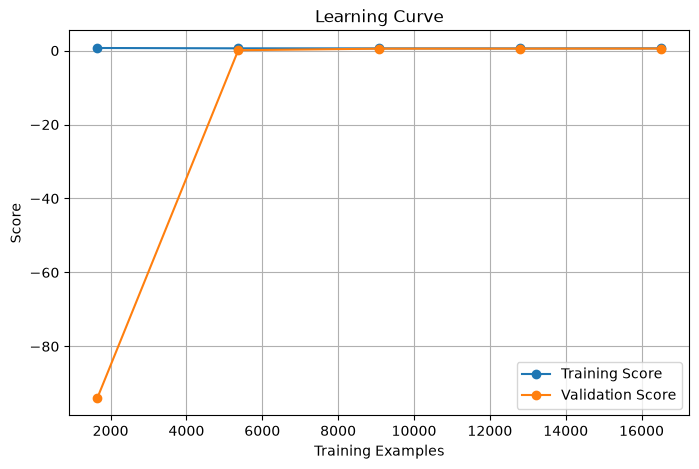

In [22]:
train_sizes, train_scores, test_scores = learning_curve(LinearRegression(),X,y,cv=5)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_mean, marker='o', label="Training Score")

plt.plot(train_sizes, test_mean, marker='o', label="Validation Score")

plt.xlabel("Training Examples")

plt.ylabel("Score")

plt.title("Learning Curve")

plt.legend()

plt.grid(True)

plt.show()

### Learning Curve Analysis

The learning curve illustrates how the model's performance changes as the amount of training data increases.

If the training and validation scores become close as more data is added, the model is likely generalizing well.

A large gap between the two curves may indicate overfitting, while consistently low scores may indicate underfitting.

In [23]:
def load_data(file_name):
    return pd.read_csv(file_name)


def split_dataset(data, target, test_size):

    X = data.drop(target, axis=1)
    y = data[target]

    return train_test_split(X,y,test_size=test_size,random_state=42)


def train_model(X_train, y_train):

    model = LinearRegression()

    model.fit(X_train, y_train)

    return model


def evaluate_model(model, X_test, y_test):

    predictions = model.predict(X_test)

    mse = mean_squared_error(y_test, predictions)

    r2 = r2_score(y_test, predictions)

    print("Mean Squared Error:", mse)

    print("R² Score:", r2)

In [24]:
data = load_data("california_housing.csv")

X_train, X_test, y_train, y_test = split_dataset(
    data,
    "MedHouseVal",
    0.2
)

model = train_model(X_train, y_train)

evaluate_model(model, X_test, y_test)

Mean Squared Error: 0.5558915986952437
R² Score: 0.5757877060324512


# Bonus Task – Polynomial Regression

In [ ]:
# Create polynomial features (Degree = 2)

poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

# Split data

X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly,y,test_size=0.2,random_state=42)

# Train Polynomial Regression Model

poly_model = LinearRegression()

poly_model.fit(X_train_poly, y_train_poly)

# Predictions

poly_predictions = poly_model.predict(X_test_poly)

# Evaluation

poly_mse = mean_squared_error(y_test_poly, poly_predictions)

poly_r2 = r2_score(y_test_poly, poly_predictions)

print("Polynomial Regression Results")
print("------------------------------")
print("Mean Squared Error:", poly_mse)
print("R² Score:", poly_r2)

Polynomial Regression Results
------------------------------
Mean Squared Error: 0.6045383165381626
R² Score: 0.538664396706364


In [26]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Polynomial Regression"],
    "MSE": [mse, poly_mse],
    "R² Score": [r2, poly_r2]
})

comparison

,Model,MSE,R² Score
0,Linear Regression,0.559002,0.580835
1,Polynomial Regression,0.604538,0.538664


## Polynomial Regression Comparison

The Polynomial Regression model was trained using degree 2 polynomial features.

Compared to the Linear Regression model, Polynomial Regression can capture more complex relationships between the features and the target variable.

If the Polynomial Regression model achieves a lower Mean Squared Error (MSE) and a higher R² score on the test set, it indicates better generalization. However, if the training performance improves significantly while the testing performance decreases, it suggests overfitting.

In this project, the comparison between both models helps determine whether increasing model complexity improves predictive performance.